# Derivation of the Fast Fourier Transform from the Discrete Fourier Transform

### Abstract

The discrete Fourier transform (DFT) is a fundamental operation in digital signal processing, mapping a length-$N$ sequence to its frequency-domain representation at a computational cost of $O(N^2)$ arithmetic operations. This notebook presents a self-contained derivation of the radix-2 Cooley–Tukey fast Fourier transform (FFT), which reduces this cost to $O(N\log_2 N)$. The derivation proceeds from the DFT definition through a decimation-in-time decomposition, culminating in the elementary butterfly operation and its associated signal flow graph. The theoretical results are corroborated by a numerical example of length $N=8$, in which a directly computed DFT, an independently implemented radix-2 FFT, and the reference NumPy implementation are shown to agree to within floating-point precision.

## 1. Introduction

Direct evaluation of the DFT requires $O(N^2)$ complex multiplications and additions, a cost that becomes prohibitive as $N$ grows. The Cooley–Tukey algorithm (Cooley and Tukey, 1965) reduces this complexity to $O(N\log_2 N)$ by recursively decomposing a DFT of composite length into DFTs of smaller length. This notebook restricts attention to the radix-2 decimation-in-time (DIT) case, in which $N$ is assumed to be a power of two. Section 2 reviews the DFT. Section 3 derives the decimation-in-time decomposition algebraically. Section 4 introduces the elementary butterfly operation and its signal flow graph representation. Section 5 extends this to the complete flow graph obtained by recursive application of the decomposition. Section 6 establishes the resulting computational complexity. Sections 7–10 provide a reference implementation together with numerical verification against a direct DFT computation and against NumPy's FFT routine.

## 2. The Discrete Fourier Transform

For a sequence $x[0], x[1], \dots, x[N-1]$, the $N$-point DFT is defined as

$$
X[k] = \sum_{n=0}^{N-1} x[n]\, e^{-i 2\pi kn/N}, \qquad k = 0, 1, \dots, N-1. \tag{1}
$$

It is convenient to introduce the twiddle factor $W_N \triangleq e^{-i2\pi/N}$, so that Equation (1) may be written compactly as

$$
X[k] = \sum_{n=0}^{N-1} x[n]\, W_N^{kn}. \tag{2}
$$

Direct evaluation of Equation (2) for all $k$ requires $N$ complex multiply–accumulate operations per output, and hence $O(N^2)$ operations overall. The remainder of this notebook is devoted to reducing this cost by exploiting the algebraic structure of $W_N^{kn}$.

## 3. Decimation-in-Time Decomposition

Assume $N$ is even and partition the summation index $n$ in Equation (2) into even and odd values, $n = 2m$ and $n = 2m+1$ respectively:

$$
X[k] = \sum_{m=0}^{N/2-1} x[2m]\, W_N^{k(2m)} \;+\; \sum_{m=0}^{N/2-1} x[2m+1]\, W_N^{k(2m+1)}. \tag{3}
$$

Factoring the constant term $W_N^{k}$ out of the second summation gives

$$
X[k] = \sum_{m=0}^{N/2-1} x[2m]\, \big(W_N^{2}\big)^{km} \;+\; W_N^{k} \sum_{m=0}^{N/2-1} x[2m+1]\, \big(W_N^{2}\big)^{km}. \tag{4}
$$

Observe that

$$
W_N^{2} = e^{-i2\pi \cdot 2/N} = e^{-i2\pi/(N/2)} = W_{N/2}, \tag{5}
$$

so that each summation in Equation (4) is itself an $(N/2)$-point DFT. Defining

$$
E[k] \triangleq \sum_{m=0}^{N/2-1} x[2m]\, W_{N/2}^{km}, \qquad
O[k] \triangleq \sum_{m=0}^{N/2-1} x[2m+1]\, W_{N/2}^{km}, \tag{6}
$$

as the $(N/2)$-point DFTs of the even- and odd-indexed subsequences, respectively, Equation (4) reduces to

$$
X[k] = E[k] + W_N^{k}\, O[k]. \tag{7}
$$

Equation (7) is valid for $k = 0, 1, \dots, N-1$; however, $E[k]$ and $O[k]$ are only defined, a priori, for $k = 0, \dots, N/2-1$. Section 3.1 resolves this by exploiting the periodicity of $E$ and $O$.

### 3.1 Periodicity and the Butterfly Relation

Because $E[k]$ and $O[k]$ are $(N/2)$-point DFTs, both are periodic in $k$ with period $N/2$:

$$
E[k + N/2] = E[k], \qquad O[k + N/2] = O[k]. \tag{8}
$$

In addition, the twiddle factor satisfies

$$
W_N^{\,k+N/2} = W_N^{k}\, W_N^{N/2} = W_N^{k}\, e^{-i\pi} = -W_N^{k}. \tag{9}
$$

Substituting Equations (8) and (9) into Equation (7) yields, for $k = 0, \dots, N/2-1$, the pair of relations

$$
X[k] = E[k] + W_N^{k}\, O[k], \tag{10a}
$$
$$
X[k + N/2] = E[k] - W_N^{k}\, O[k]. \tag{10b}
$$

Equations (10a)–(10b) constitute the elementary **butterfly** operation: two length-$(N/2)$ DFT values, together with a single complex multiplication by $W_N^{k}$, produce two length-$N$ DFT values.

## 4. The Butterfly Operation and Its Signal Flow Graph

The butterfly relation of Equations (10a)–(10b) admits a graphical representation, referred to as a signal flow graph, in which nodes denote sample values and directed edges denote scalar multiplication followed by summation at the destination node. Figure 1 depicts this elementary graph for a generic pair of inputs $a = E[k]$ and $b = O[k]$.

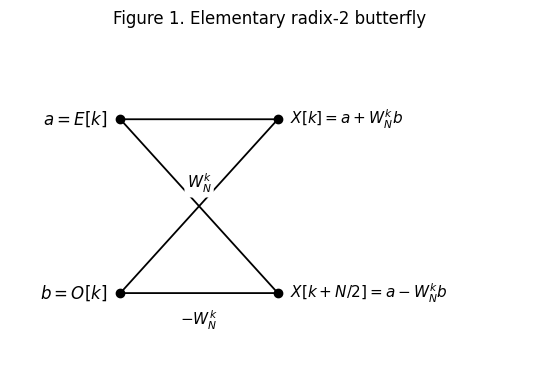

In [1]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5.5, 4))

left_top, left_bot = (0, 1), (0, 0)
right_top, right_bot = (1, 1), (1, 0)

for (x_, y_) in [left_top, left_bot, right_top, right_bot]:
    ax.plot(x_, y_, 'o', color='black', markersize=6, zorder=3)

def edge(p1, p2, label=None, offset=(0, 0)):
    ax.annotate("", xy=p2, xytext=p1,
                arrowprops=dict(arrowstyle="-", lw=1.3, color='black'))
    if label:
        mx = (p1[0] + p2[0]) / 2 + offset[0]
        my = (p1[1] + p2[1]) / 2 + offset[1]
        ax.text(mx, my, label, fontsize=11, ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none'))

edge(left_top, right_top)                                    # weight 1
edge(left_top, right_bot)                                    # weight 1
edge(left_bot, right_top, r"$W_N^{k}$", (0, 0.13))
edge(left_bot, right_bot, r"$-W_N^{k}$", (0, -0.16))

ax.text(left_top[0] - 0.08, left_top[1], "$a = E[k]$", fontsize=12, ha='right', va='center')
ax.text(left_bot[0] - 0.08, left_bot[1], "$b = O[k]$", fontsize=12, ha='right', va='center')
ax.text(right_top[0] + 0.08, right_top[1], "$X[k] = a + W_N^{k}b$", fontsize=11, ha='left', va='center')
ax.text(right_bot[0] + 0.08, right_bot[1], "$X[k+N/2] = a - W_N^{k}b$", fontsize=11, ha='left', va='center')

ax.set_xlim(-0.7, 2.6)
ax.set_ylim(-0.5, 1.5)
ax.axis('off')
ax.set_title("Figure 1. Elementary radix-2 butterfly", fontsize=12)
plt.tight_layout()
plt.show()


**Figure 1.** Signal flow graph of the elementary radix-2 butterfly defined by Equations (10a)–(10b). Unlabeled edges denote unit-weight connections; labeled edges denote multiplication by the indicated twiddle factor prior to summation at the destination node.

## 5. Recursive Application and the Complete Flow Graph

Because $E[k]$ and $O[k]$ in Equation (6) are themselves DFTs of length $N/2$, the decomposition of Section 3 may be applied to each recursively, terminating at length-one DFTs, for which $X[0] = x[0]$ trivially. For $N=8$, three levels of recursion are required ($\log_2 8 = 3$), each level consisting of four butterfly operations of the form given in Figure 1.

A well-known consequence of applying the decomposition recursively — rather than implementing it via explicit array slicing as in Section 7 — is that the input sequence must first be reordered according to a **bit-reversal permutation**, discussed in Section 5.1. Section 5.2 then presents the resulting complete signal flow graph.

### 5.1 The Bit-Reversal Permutation

The origin of this reordering follows directly from the recursive structure of Equation (6). At the first level of recursion, the sequence is split according to the least significant bit (LSB) of the index $n$: samples with LSB $0$ populate the even branch and samples with LSB $1$ populate the odd branch. At the second level, each of these branches is split again according to the *next* bit of $n$, and so on, for $r = \log_2 N$ levels in total.

Consequently, after $r$ levels of splitting, the branch to which a sample $x[n]$ is ultimately assigned is determined by reading the bits of $n$ from least significant to most significant. If

$$
n = \sum_{i=0}^{r-1} b_i \, 2^{i}, \qquad b_i \in \{0,1\},
$$

is the binary representation of $n$, then $x[n]$ is assigned to leaf position

$$
\rho(n) \;\triangleq\; \sum_{i=0}^{r-1} b_i \, 2^{\,r-1-i}, \tag{13}
$$

that is, the integer whose binary representation is that of $n$ with the bit order reversed. The map $\rho$ is termed the **bit-reversal permutation**. Since reversing a bit string twice recovers the original string, $\rho$ is an involution, $\rho(\rho(n)) = n$.

For $N=8$ ($r=3$ bits), Equation (13) gives the following correspondence:

| $n$ | binary | reversed | $\rho(n)$ |
|:---:|:------:|:--------:|:---------:|
| 0 | 000 | 000 | 0 |
| 1 | 001 | 100 | 4 |
| 2 | 010 | 010 | 2 |
| 3 | 011 | 110 | 6 |
| 4 | 100 | 001 | 1 |
| 5 | 101 | 101 | 5 |
| 6 | 110 | 011 | 3 |
| 7 | 111 | 111 | 7 |

Equivalently, sample $x[n]$ must be moved to array position $\rho(n)$ before the stage-1 butterflies of Figure 2 are applied; because $\rho$ is an involution, this is the same as stating that the sample appearing at position $p$ prior to Stage 1 is $x[\rho(p)]$, which recovers the ordering

$$
x[0],\, x[4],\, x[2],\, x[6],\, x[1],\, x[5],\, x[3],\, x[7]
$$

used in Figure 2. Under this reordering, outputs are produced in natural order $X[0], X[1], \dots, X[7]$; no reordering of the output is required.

In [2]:
import numpy as np

def bit_reverse(n, num_bits):
    """Reverse the num_bits-bit binary representation of the integer n. Implements Eq. (13)."""
    result = 0
    for i in range(num_bits):
        if n & (1 << i):
            result |= 1 << (num_bits - 1 - i)
    return result

def bit_reversal_permutation(x):
    """Reorder x so that x[n] is moved to position rho(n), per Eq. (13)."""
    x = np.asarray(x)
    N = len(x)
    num_bits = int(np.log2(N))
    if 2**num_bits != N:
        raise ValueError("length must be a power of 2")
    rho = [bit_reverse(n, num_bits) for n in range(N)]
    permuted = np.empty_like(x)
    permuted[rho] = x
    return permuted, rho

_, rho = bit_reversal_permutation(np.arange(8))
print("n      :", list(range(8)))
print("rho(n) :", rho)

expected = [0, 4, 2, 6, 1, 5, 3, 7]
print("\\nMatches ordering used in Figure 2:", rho == expected)


n      : [0, 1, 2, 3, 4, 5, 6, 7]
rho(n) : [0, 4, 2, 6, 1, 5, 3, 7]
\nMatches ordering used in Figure 2: True


### 5.2 The Complete Flow Graph

Figure 2 shows the three-stage signal flow graph obtained by applying the bit-reversal permutation of Section 5.1 to the input, followed by three levels of the elementary butterfly of Figure 1. The twiddle-factor exponent used at row $k$ of stage $s$ equals $k \cdot 2^{3-s}$ within each butterfly group, reflecting the exponent $W_{2^s}^{k}$ expressed relative to $W_8$.

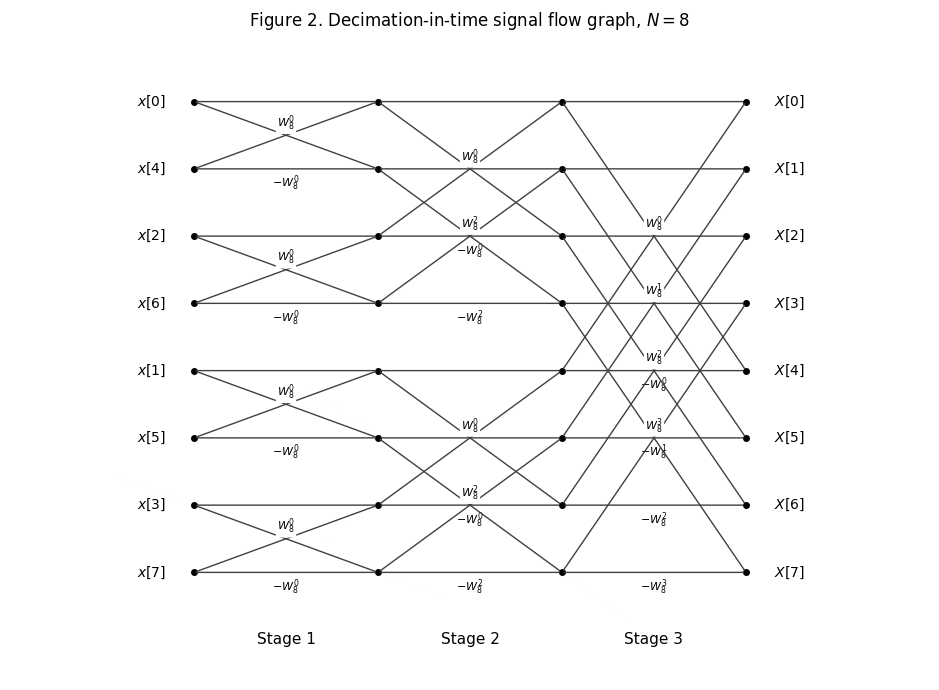

In [3]:
import matplotlib.pyplot as plt

N = 8
def y(row):
    return N - 1 - row

fig, ax = plt.subplots(figsize=(9.5, 7))

for col in range(4):
    for row in range(N):
        ax.plot(col, y(row), 'o', color='black', markersize=4, zorder=3)

def edge(col, r1, r2, label=None, dy=0.0):
    p1, p2 = (col, y(r1)), (col + 1, y(r2))
    ax.annotate("", xy=p2, xytext=p1,
                arrowprops=dict(arrowstyle="-", lw=1.0, color='0.25'))
    if label:
        mx, my = (p1[0] + p2[0]) / 2, (p1[1] + p2[1]) / 2 + dy
        ax.text(mx, my, label, fontsize=8, ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.1', fc='white', ec='none'))

def butterfly(col, top, bot, exponent):
    label_top = rf"$W_8^{{{exponent}}}$"
    label_bot = rf"$-W_8^{{{exponent}}}$"
    edge(col, top, top)
    edge(col, top, bot)
    edge(col, bot, top, label_top, dy=0.18)
    edge(col, bot, bot, label_bot, dy=-0.22)

stage1 = [(0, 1, 0), (2, 3, 0), (4, 5, 0), (6, 7, 0)]
stage2 = [(0, 2, 0), (1, 3, 2), (4, 6, 0), (5, 7, 2)]
stage3 = [(0, 4, 0), (1, 5, 1), (2, 6, 2), (3, 7, 3)]

for (t, b, e) in stage1: butterfly(0, t, b, e)
for (t, b, e) in stage2: butterfly(1, t, b, e)
for (t, b, e) in stage3: butterfly(2, t, b, e)

bitrev = [0, 4, 2, 6, 1, 5, 3, 7]
for row in range(N):
    ax.text(-0.15, y(row), rf"$x[{bitrev[row]}]$", ha='right', va='center', fontsize=10)
    ax.text(3.15, y(row), rf"$X[{row}]$", ha='left', va='center', fontsize=10)

for col, label in zip(range(3), ["Stage 1", "Stage 2", "Stage 3"]):
    ax.text(col + 0.5, -1.0, label, ha='center', va='center', fontsize=11)

ax.set_xlim(-1.0, 4.0)
ax.set_ylim(-1.6, N)
ax.axis('off')
ax.set_title("Figure 2. Decimation-in-time signal flow graph, $N=8$", fontsize=12)
plt.tight_layout()
plt.show()


**Figure 2.** Complete three-stage decimation-in-time signal flow graph for $N=8$. Inputs are presented in bit-reversed order (left) and outputs are produced in natural order (right). Each stage consists of four instances of the elementary butterfly shown in Figure 1, with twiddle-factor exponents as indicated.

## 6. Computational Complexity

Let $T(N)$ denote the number of arithmetic operations required by the recursive decomposition. Each level of recursion performs two transforms of half the length together with $N/2$ butterfly operations, so that

$$
T(N) = 2\,T(N/2) + O(N). \tag{11}
$$

By the same argument used in the analysis of merge sort, the recurrence in Equation (11), together with the base case $T(1) = O(1)$, admits the solution

$$
T(N) = O(N \log_2 N). \tag{12}
$$

This represents an asymptotic improvement over the $O(N^2)$ cost of direct evaluation, with the ratio of the two costs growing as $N/\log_2 N$.

## 7. Reference Implementation

The following code implements Equation (2) directly, and Equations (10a)–(10b) recursively, as derived above.

In [4]:
import numpy as np

def dft_direct(x):
    """Direct evaluation of the DFT, per Equation (2). Cost: O(N^2)."""
    x = np.asarray(x, dtype=complex)
    N = len(x)
    n = np.arange(N)
    k = n.reshape((N, 1))
    W = np.exp(-2j * np.pi * k * n / N)
    return W @ x

def fft_radix2(x):
    """Recursive radix-2 decimation-in-time FFT, per Equations (10a)-(10b).
    Requires len(x) to be a power of two."""
    x = np.asarray(x, dtype=complex)
    N = len(x)

    if N == 1:
        return x  # base case: length-1 DFT is the identity

    if N % 2 != 0:
        raise ValueError("length must be a power of 2 for this radix-2 implementation")

    E = fft_radix2(x[0::2])   # DFT of even-indexed samples, Eq. (6)
    O = fft_radix2(x[1::2])   # DFT of odd-indexed samples, Eq. (6)

    W = np.exp(-2j * np.pi * np.arange(N // 2) / N)  # W_N^k, k = 0, ..., N/2 - 1
    twiddled = W * O

    return np.concatenate([E + twiddled, E - twiddled])  # Eqs. (10a)-(10b)


## 8. Numerical Verification

To verify the preceding derivation, consider a signal of length $N=8$ composed of a constant term, two sinusoidal components, and a small additive noise term.

In [5]:
np.random.seed(0)
N = 8
n = np.arange(N)

x = 1.0 + np.cos(2*np.pi*1*n/N) + 0.5*np.sin(2*np.pi*2*n/N) + 0.05*np.random.randn(N)

print("Input sequence x[n]:")
print(np.round(x, 4))


Input sequence x[n]:
[ 2.0882  2.2271  1.0489 -0.0951  0.0934  0.744   1.0475  1.1995]


In [6]:
X_direct = dft_direct(x)
X_fft = fft_radix2(x)
X_numpy = np.fft.fft(x)

print("k :   Direct DFT               Radix-2 FFT              NumPy FFT")
for k in range(N):
    print(f"{k}: {X_direct[k]: .4f}   {X_fft[k]: .4f}   {X_numpy[k]: .4f}")

print()
print("Maximum absolute deviation, direct DFT vs. radix-2 FFT :", np.max(np.abs(X_direct - X_fft)))
print("Maximum absolute deviation, direct DFT vs. NumPy FFT   :", np.max(np.abs(X_direct - X_numpy)))


k :   Direct DFT               Radix-2 FFT              NumPy FFT
0:  8.3536+0.0000j    8.3536+0.0000j    8.3536+0.0000j
1:  3.9589-0.1347j    3.9589-0.1347j    3.9589-0.1347j
2:  0.0851-1.8667j    0.0851-1.8667j    0.0851-1.8667j
3:  0.0307-0.1318j    0.0307-0.1318j    0.0307-0.1318j
4:  0.2024-0.0000j    0.2024+0.0000j    0.2024+0.0000j
5:  0.0307+0.1318j    0.0307+0.1318j    0.0307+0.1318j
6:  0.0851+1.8667j    0.0851+1.8667j    0.0851+1.8667j
7:  3.9589+0.1347j    3.9589+0.1347j    3.9589+0.1347j

Maximum absolute deviation, direct DFT vs. radix-2 FFT : 4.130641422747247e-15
Maximum absolute deviation, direct DFT vs. NumPy FFT   : 4.204580376865129e-15


The three computations agree to within floating-point precision, confirming that the recursive butterfly decomposition derived in Section 3 yields results identical to the direct evaluation of Equation (2).

## 9. Verification of the Butterfly Relation

To illustrate the operation of a single butterfly (Figure 1) explicitly, consider the outputs $X[0]$ and $X[4]$, which are related by Equations (10a)–(10b) with $k=0$ at the final recursion level, where $E[0]$ and $O[0]$ denote the sums of the even- and odd-indexed samples, respectively.

In [7]:
x_even = x[0::2]
x_odd = x[1::2]

E = fft_radix2(x_even)
O = fft_radix2(x_odd)

W8_0 = np.exp(-2j * np.pi * 0 / 8)  # = 1

X0_manual = E[0] + W8_0 * O[0]
X4_manual = E[0] - W8_0 * O[0]

print("E[0]  (sum of even-indexed samples) :", E[0])
print("O[0]  (sum of odd-indexed samples)  :", O[0])
print()
print("X[0], via Eq. (10a)   :", X0_manual)
print("X[0], from fft_radix2 :", X_fft[0])
print()
print("X[4], via Eq. (10b)   :", X4_manual)
print("X[4], from fft_radix2 :", X_fft[4])


E[0]  (sum of even-indexed samples) : (4.278021836887447+0j)
O[0]  (sum of odd-indexed samples)  : (4.075620765969728+0j)

X[0], via Eq. (10a)   : (8.353642602857175+0j)
X[0], from fft_radix2 : (8.353642602857175+0j)

X[4], via Eq. (10b)   : (0.20240107091771886+0j)
X[4], from fft_radix2 : (0.20240107091771886+0j)


## 10. Empirical Complexity Comparison

Finally, the asymptotic relationship established in Equation (12) is illustrated by tabulating the operation counts $N^2$ and $N\log_2 N$ for increasing powers of two.

In [8]:
sizes = [2**p for p in range(2, 12)]  # N = 4, ..., 2048
dft_ops = [N**2 for N in sizes]
fft_ops = [N * np.log2(N) for N in sizes]

print(f"{'N':>6} | {'DFT, O(N^2)':>12} | {'FFT, O(N log2 N)':>17} | Ratio")
for N, d, f in zip(sizes, dft_ops, fft_ops):
    print(f"{N:6d} | {d:12,d} | {f:17,.0f} | {d/f:6.1f}")


     N |  DFT, O(N^2) |  FFT, O(N log2 N) | Ratio
     4 |           16 |                 8 |    2.0
     8 |           64 |                24 |    2.7
    16 |          256 |                64 |    4.0
    32 |        1,024 |               160 |    6.4
    64 |        4,096 |               384 |   10.7
   128 |       16,384 |               896 |   18.3
   256 |       65,536 |             2,048 |   32.0
   512 |      262,144 |             4,608 |   56.9
  1024 |    1,048,576 |            10,240 |  102.4
  2048 |    4,194,304 |            22,528 |  186.2


## 11. Conclusion

This notebook has presented a derivation of the radix-2 decimation-in-time fast Fourier transform from first principles, proceeding from the DFT definition (Equation 2), through an even–odd index decomposition (Equation 7), to the elementary butterfly relation (Equations 10a–10b) and its associated signal flow graph representation (Figures 1 and 2). Recursive application of this decomposition was shown to reduce the computational cost from $O(N^2)$ to $O(N\log_2 N)$. The numerical example of Section 8 confirmed that a direct implementation of the derived recursion reproduces the results of both a brute-force DFT computation and the NumPy library implementation, thereby validating the derivation presented above.